In [1]:
# Import necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

In [2]:
# Load the dataset and display its shape and head
df = pd.read_csv(
    "/content/customer_segments.csv"
)

print(df.shape)
df.head()

(44787, 25)


,customer_unique_id,customer_state,frequency,recency_days,monetary_value,avg_order_value,total_items_purchased,avg_freight_cost,total_orders,delivered_order_rate,...,unique_categories,unique_sellers,avg_review_score,good_review_rate,bad_review_rate,avg_installments,total_payment_value,weekend_purchase_ratio,monthly_purchase_frequency,cluster
0,861eff4711a542e4b93843c6dd7febb0,SP,1,519,124.99,124.99,1,21.88,1,1.0,...,1,1,4.0,1.0,0.0,2.0,146.87,0.0,0.041667,0
1,290c77bc529b7ac935b93aa66c333dc3,SP,1,277,289.00,289.00,1,46.48,1,1.0,...,1,1,5.0,1.0,0.0,8.0,335.48,0.0,0.041667,0
2,060e732b5b29e8181a18229c7b0b2b5e,SP,1,151,139.94,139.94,1,17.79,1,1.0,...,1,1,5.0,1.0,0.0,7.0,157.73,1.0,0.041667,0
3,259dac757896d24d7702b9acbbff3f3c,SP,1,218,149.94,149.94,1,23.36,1,1.0,...,1,1,5.0,1.0,0.0,1.0,173.30,0.0,0.041667,0
4,345ecd01c38d18a9036ed96c73b8d066,SP,1,80,230.00,230.00,1,22.25,1,1.0,...,1,1,5.0,1.0,0.0,8.0,252.25,1.0,0.041667,0


In [3]:
# Create a new target variable 'repeat_customer'
df["repeat_customer"] = (
    df["frequency"] > 1
).astype(int)

In [4]:
# Display the distribution of the 'repeat_customer' variable
print(
    df["repeat_customer"]
    .value_counts()
)

print()

print(
    df["repeat_customer"]
    .value_counts(normalize=True)
    * 100
)

repeat_customer
0    42644
1     2143
Name: count, dtype: int64

repeat_customer
0    95.215129
1     4.784871
Name: proportion, dtype: float64


In [5]:
# Define columns to be dropped
drop_cols = [
    "customer_unique_id",
    "frequency",
    "total_orders",
    "monthly_purchase_frequency"
]

In [6]:
# Separate features (X) and target (y)
X = df.drop(
    columns=drop_cols +
    ["repeat_customer"],
    errors="ignore"
)

y = df["repeat_customer"]

In [7]:
# Perform one-hot encoding for categorical features
X = pd.get_dummies(
    X,
    columns=["customer_state"],
    drop_first=True
)

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
)

In [9]:
# Impute missing values using the median strategy
imputer = SimpleImputer(
    strategy="median"
)

X_train = imputer.fit_transform(
    X_train
)

X_test = imputer.transform(
    X_test
)

In [10]:
# Scale numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [11]:
# Train and evaluate a Logistic Regression model
log_model = LogisticRegression(
    max_iter=2000
)

log_model.fit(
    X_train,
    y_train
)

log_preds = log_model.predict(
    X_test
)

In [12]:
# Define a function to evaluate model performance
def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    print(f"\n{model_name}")

    print("="*40)

    print(
        "Accuracy:",
        accuracy_score(
            y_true,
            y_pred
        )
    )

    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred
        )
    )

    print(
        "Recall:",
        recall_score(
            y_true,
            y_pred
        )
    )

    print(
        "F1:",
        f1_score(
            y_true,
            y_pred
        )
    )

In [13]:
# Evaluate the Logistic Regression model
evaluate_model(
    "Logistic Regression",
    y_test,
    log_preds
)


Logistic Regression
Accuracy: 0.9934137084170573
Precision: 0.9792746113989638
Recall: 0.8811188811188811
F1: 0.9276073619631902


In [14]:
# Train and evaluate a Random Forest Classifier model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train,
    y_train
)

rf_preds = rf_model.predict(
    X_test
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_preds
)


Random Forest
Accuracy: 0.9926322839919625
Precision: 0.9571788413098237
Recall: 0.8857808857808858
F1: 0.9200968523002422


In [15]:
# Train and evaluate an XGBoost Classifier model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_preds = xgb_model.predict(
    X_test
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_preds
)


XGBoost
Accuracy: 0.999330207635633
Precision: 0.993006993006993
Recall: 0.993006993006993
F1: 0.993006993006993


In [16]:
# Create a DataFrame to compare model results
results = pd.DataFrame({
    "Model": [
        "Logistic",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(
            y_test,
            log_preds
        ),
        accuracy_score(
            y_test,
            rf_preds
        ),
        accuracy_score(
            y_test,
            xgb_preds
        )
    ],
    "F1": [
        f1_score(
            y_test,
            log_preds
        ),
        f1_score(
            y_test,
            rf_preds
        ),
        f1_score(
            y_test,
            xgb_preds
        )
    ]
})

results.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,F1
2,XGBoost,0.999330,0.993007
0,Logistic,0.993414,0.927607
1,Random Forest,0.992632,0.920097


In [17]:
# Calculate and sort feature importances for the Random Forest model
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance":
    rf_model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

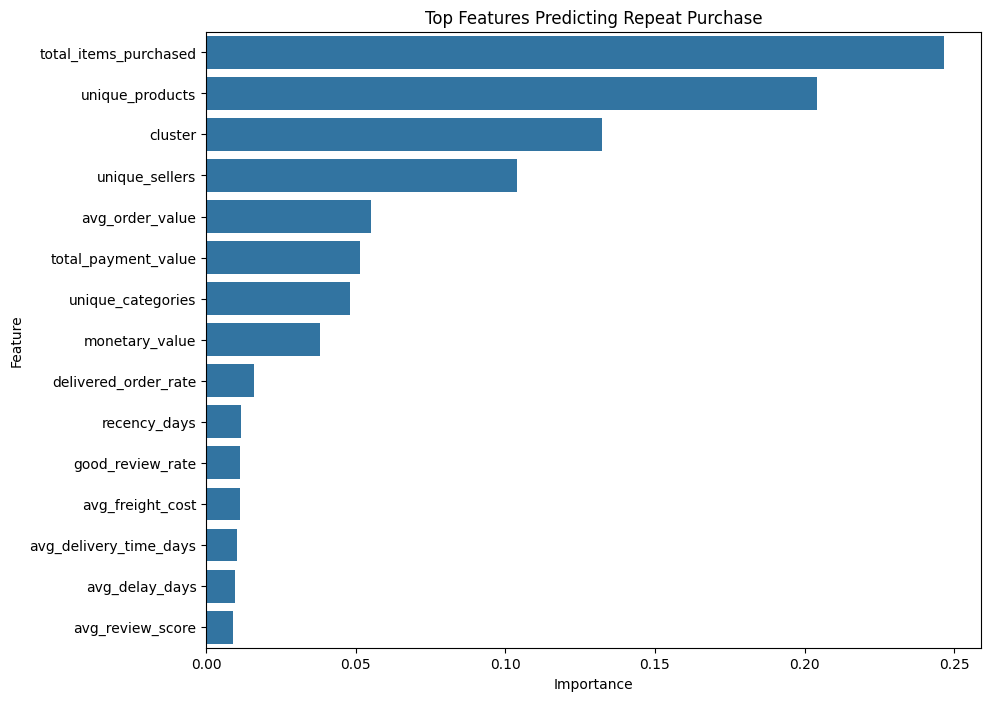

In [18]:
# Visualize the top features predicting repeat purchase
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Predicting Repeat Purchase"
)

plt.show()

In [19]:
# Save the trained Random Forest model
joblib.dump(
    rf_model,
    "repeat_purchase_model.pkl"
)

['repeat_purchase_model.pkl']

In [20]:
# Save the scaler and imputer objects
joblib.dump(
    scaler,
    "repeat_purchase_scaler.pkl"
)

joblib.dump(
    imputer,
    "repeat_purchase_imputer.pkl"
)

['repeat_purchase_imputer.pkl']

In [21]:
# Save the model comparison results to a CSV file
results.to_csv(
    "repeat_purchase_results.csv",
    index=False
)